# Imports:

In [1]:
import pandas as pd
import json
from torchvision import transforms
import uuid
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from utils.utils_augmentation import *
from utils.utils_model import *

In [2]:
# 1. Load the CSVs without 'dx_encoded' (since it's not in the file)
train_df = pd.read_csv('data/train_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
val_df = pd.read_csv('data/val_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
test_df = pd.read_csv('data/test_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path','dx']]

# 2. Re-create the encoded column using the loaded dictionary
train_df["dx_encoded"] = train_df["dx"].map(label2idx).astype(int)
val_df["dx_encoded"] = val_df["dx"].map(label2idx).astype(int)
test_df["dx_encoded"] = test_df["dx"].map(label2idx).astype(int)

In [3]:
train_df.head()

,image_id,dataset,lesion_id,cleaned_path,dx,dx_encoded
0,ISIC_0028291,vidir_modern,HAM_0006253,./data\HAM10000_cleaned\train\ISIC_0028291_cle...,mel,4
1,ISIC_0028308,rosendahl,HAM_0003752,./data\HAM10000_cleaned\train\ISIC_0028308_cle...,bkl,2
2,ISIC_0028286,vidir_molemax,HAM_0005470,./data\HAM10000_cleaned\train\ISIC_0028286_cle...,nv,5
3,ISIC_0028288,rosendahl,HAM_0004709,./data\HAM10000_cleaned\train\ISIC_0028288_cle...,mel,4
4,ISIC_0028313,vidir_molemax,HAM_0004166,./data\HAM10000_cleaned\train\ISIC_0028313_cle...,nv,5


In [4]:
train_df = train_df.rename(columns={'cleaned_path': 'image_path'})
val_df = val_df.rename(columns={'cleaned_path': 'image_path'})
test_df = test_df.rename(columns={'cleaned_path': 'image_path'})

train_df['dataset'] = 'original'
val_df['dataset'] = 'original'
test_df['dataset'] = 'original'

In [5]:
train_df.head()

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
0,ISIC_0028291,original,HAM_0006253,./data\HAM10000_cleaned\train\ISIC_0028291_cle...,mel,4
1,ISIC_0028308,original,HAM_0003752,./data\HAM10000_cleaned\train\ISIC_0028308_cle...,bkl,2
2,ISIC_0028286,original,HAM_0005470,./data\HAM10000_cleaned\train\ISIC_0028286_cle...,nv,5
3,ISIC_0028288,original,HAM_0004709,./data\HAM10000_cleaned\train\ISIC_0028288_cle...,mel,4
4,ISIC_0028313,original,HAM_0004166,./data\HAM10000_cleaned\train\ISIC_0028313_cle...,nv,5


# Data Augmentation

In [6]:
# TEST (CPU - 1min)
output_csv = os.path.join(base_path, "augmented_metadata.csv")

aug_train_df = run_augmentation_pipeline(
            train_df=train_df,
            undersample=True,
            undersample_size=4500,
            output_path=output_csv
        )

AUGMENTATION PIPELINE

[1/3] Generating augmented images...
Submitting task for augmenting mel (multiplier: 3)
Submitting task for augmenting bkl (multiplier: 3)
Submitting task for augmenting bcc (multiplier: 4)
Submitting task for augmenting akiec (multiplier: 5)
Submitting task for augmenting vasc (multiplier: 8)
Submitting task for augmenting df (multiplier: 8)


Generating all augmented images: 100%|██████████| 6/6 [01:26<00:00, 14.46s/it]

Generated 7115 augmented images

[2/3] Undersampling 'nv' to 4500 samples...
Undersampled to 4500 samples

[3/3] Combining datasets...
Final dataset size: 14214 samples

Saved to: ./data\augmented_metadata.csv

FINAL CLASS DISTRIBUTION
dx
akiec    1265
bcc      1624
bkl      2622
df        680
mel      2595
nv       4500
vasc      928
Name: count, dtype: int64


### Similarity Undersampler (em produção)

In [43]:
from joblib import Parallel, delayed
from sklearn.utils import shuffle
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from keras.applications import ResNet50

In [62]:
nv_paths = train_df[train_df['dx'] == 'nv'].image_path

In [ ]:
"""
model_embeddings = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def get_embedding(path, model):
    
    Generates an embedding for an image using a pre-trained ResNet50 model.

    Args:
        path (string): Input image path.

    Returns:
        array: Flattened embedding vector for the input image.
    
    image = np.array(Image.open(path).convert('RGB'))
    image = np.expand_dims(image, axis=0)
    embedding = model.predict(image, verbose=0)
    return embedding.flatten()

""""

In [ ]:
"""
def similarity_undersampler(paths, percent_to_drop):
    """
    Performs undersampling by removing similar paths based on their embeddings.

    Args:
        paths (list): List of input paths to images to be undersampled.
        percent_to_drop (float): Percentage of paths to drop based on similarity (between 0 and 1).

    Returns:
        list: Indices of the paths to keep after undersampling.
    """

    # Generating the embeddings in parallel to speed up
    with Parallel(n_jobs=-1) as parallel:
        image_embeddings = np.array(parallel(delayed(get_embedding)(img, model_embeddings) for img in tqdm(paths, leave=False)))

    # Clustering the embeddings in Number of images / (1 / percentage of drop) clusters
    # Example: If we want to drop half the class, we will have 1 / 0.5 = 2 ; Number of images / 2 clusters, distributing the images there
    num_clusters = len(image_embeddings) // round(1 / percent_to_drop)
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(image_embeddings)

    # Evaluating the redundancy of each image
    redundancy_scores = []
    # Iterating over every assigned formed cluster
    for cluster_id in tqdm(np.unique(cluster_labels)):
        # Getting the embedding of every image on the cluster
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        cluster_embeddings = image_embeddings[cluster_indices]

        # Computing the similarities between each cluster member
        similarity_matrix = cosine_similarity(cluster_embeddings)

        # The redundancy score is the sum of the similarity of each image to the ones on its cluster
        scores = similarity_matrix.sum(axis=1)
        redundancy_scores.extend(zip(cluster_indices, scores))

    redundancy_scores.sort(key=lambda x: x[1], reverse=True)

    return list(dict(redundancy_scores[:round(percent_to_drop*len(image_embeddings))]).keys())
"""

In [ ]:
#similarity_undersampler(nv_paths, 0.2)

KeyboardInterrupt: 

In [46]:
def similarity_undersample_class(X_train, y_train, percent_to_drop):
    """
    Performs undersampling by reducing the number of majority class samples.

    Args:
        X_train (array): Training images.
        y_train (array): Corresponding labels.
        percent_to_drop (float): Percentage of majority class samples to drop (0 to 1).

    Returns:
        tuple: Undersampled training data (X_train_reduced, y_train_reduced).
    """
    # If we want to drop 0% of the images, we just return the inputs
    if percent_to_drop <= 0:
        return X_train, y_train

    train_set = pd.DataFrame({'image': list(X_train), 'label': y_train})

    majority_label = pd.Series(y_train).value_counts().index[0]
    majority_images = train_set.loc[train_set.label == majority_label]

    # Getting the indexes of the most redundant images
    idxs_to_drop = majority_images.index[similarity_undersampler(majority_images.image, percent_to_drop)]
    # Dropping them
    train_set.drop(idxs_to_drop, inplace=True)

    # Transform the train set Df into separate arrays again
    X_train_reduced = np.stack(train_set.image)
    y_train_reduced = train_set.label
    X_train_reduced, y_train_reduced = shuffle(X_train_reduced, y_train_reduced, random_state=24)

    return X_train_reduced, y_train_reduced

### Visuals

In [29]:
# Function to denormalize the images, only for visualization purposes
def denormalize(tensor, mean, std):
    # Reverse: x = (z * std) + mean
    img = tensor.cpu().numpy().transpose((1, 2, 0))
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

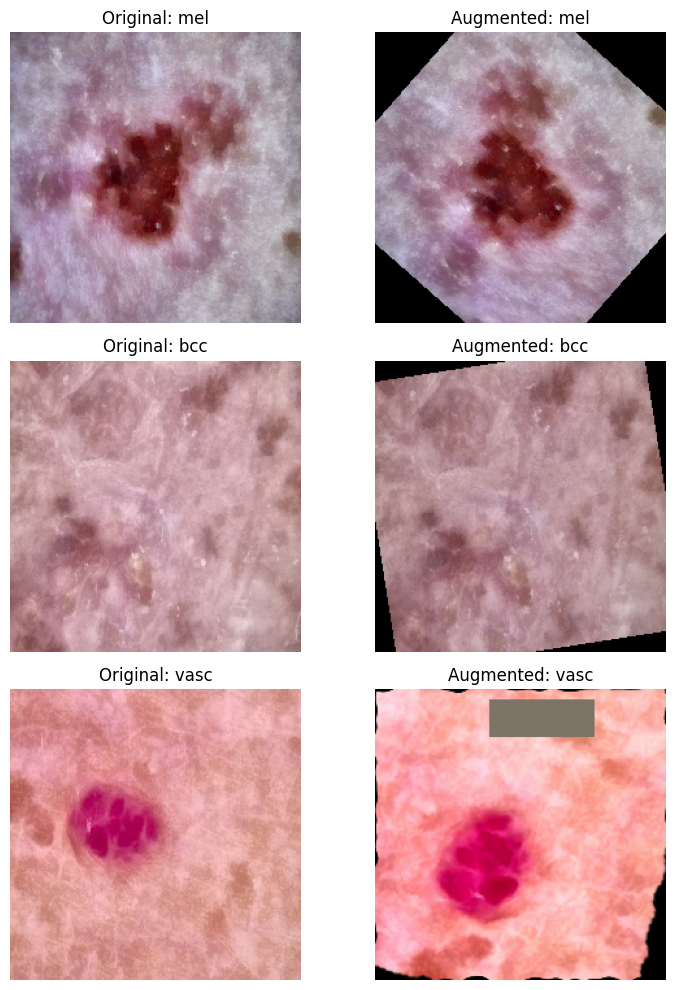

In [30]:
test_labels = ['mel', 'bcc', 'vasc']
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

for i, label in enumerate(test_labels):
    sample_path = train_df[train_df['dx'] == label].sample(1).iloc[0]['image_path']

    # open once
    with Image.open(sample_path) as img:
        img = img.convert("RGB")
        original = transforms.Resize((224, 224))(img)
        aug_tensor = strategy_map[label](original)

    aug_final = denormalize(aug_tensor, mean, std)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original: {label}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(aug_final)
    axes[i, 1].set_title(f"Augmented: {label}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

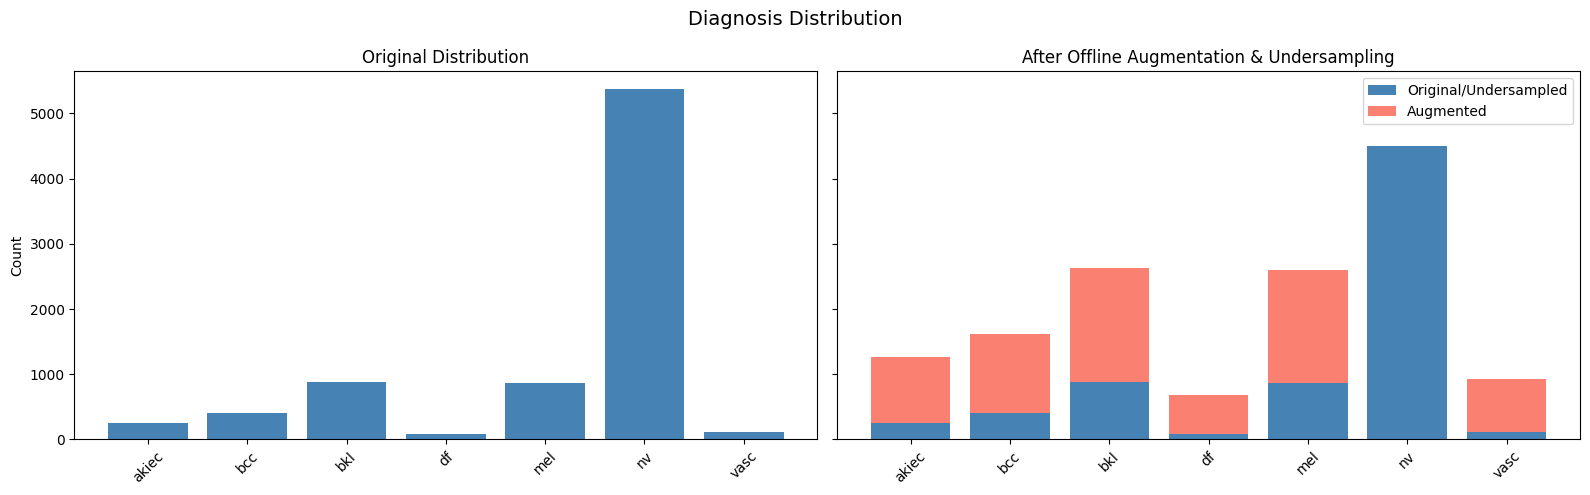

In [19]:
labels = sorted(aug_train_df["dx"].unique())
 
# Get original counts (unmodified)
original_counts = [len(train_df[train_df["dx"] == l]) for l in labels]
 
# Get final counts from augmented dataframe
final_counts = [len(aug_train_df[aug_train_df["dx"] == l]) for l in labels]
 
# For right chart: separate undersampled/original from augmented
undersampled_or_original = []
augmented_only = []
for i, label in enumerate(labels):
    if label == 'nv':
        # nv was undersampled to 4500
        undersampled_or_original.append(4500)
        augmented_only.append(final_counts[i] - 4500)
    else:
        # Other classes: original count + augmentation
        undersampled_or_original.append(original_counts[i])
        augmented_only.append(final_counts[i] - original_counts[i])
 
x = np.arange(len(labels))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
 
# ── Left: Original Distribution
axes[0].bar(x, original_counts, color="steelblue")
axes[0].set_title("Original Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_ylabel("Count")
 
# ── Right: After Augmentation & Undersampling (stacked)
axes[1].bar(x, undersampled_or_original, color="steelblue", label="Original/Undersampled")
axes[1].bar(x, augmented_only, bottom=undersampled_or_original, color="salmon", label="Augmented")
axes[1].set_title("After Offline Augmentation & Undersampling")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].legend()
 
plt.suptitle("Diagnosis Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## Validating the augmentation pipeline with a simple model

In [7]:
aug_train_df.sample(5)

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
2738,ISIC_0032183,original,HAM_0007351,./data\HAM10000_cleaned\train\ISIC_0032183_cle...,nv,5
7177,AUG_mel_addc5501,augmented,AUG_LESION_mel_536e68ff,./data\HAM10000_augmented\AUG_mel_addc5501.jpg,mel,4
12829,AUG_vasc_a3b0caab,augmented,AUG_LESION_vasc_b36310df,./data\HAM10000_augmented\AUG_vasc_a3b0caab.jpg,vasc,6
8977,AUG_bkl_2f29085f,augmented,AUG_LESION_bkl_c9ac3a33,./data\HAM10000_augmented\AUG_bkl_2f29085f.jpg,bkl,2
13438,AUG_vasc_e301620a,augmented,AUG_LESION_vasc_0a6d4363,./data\HAM10000_augmented\AUG_vasc_e301620a.jpg,vasc,6


### Setting up

In [ ]:
# Class weights
class_weights_dict = make_class_weights(aug_train_df)

In [9]:
train_ds = make_dataset(aug_train_df, shuffle=True, repeat=True)  
val_ds   = make_dataset(val_df)                               
test_ds  = make_dataset(test_df)

### Baseline Model 1

In [32]:
model_baseline = keras.Sequential([
    keras.layers.Conv2D(8, kernel_size=6, activation="relu", input_shape=(224, 224, 3)),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(N_CLASSES)
])

model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

c:\Users\tomas\anaconda3\envs\clean_ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# CPU - 2min

epochs = 10
spe = 100

history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=spe,
    class_weight=class_weights_dict
)

Epoch 1/10


100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 143ms/step - accuracy: 0.0725 - loss: 1.9662 - val_accuracy: 0.0366 - val_loss: 1.9850
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.1841 - loss: 1.9278 - val_accuracy: 0.1196 - val_loss: 1.8924
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.2047 - loss: 1.9622 - val_accuracy: 0.3317 - val_loss: 1.9029
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.1953 - loss: 1.9118 - val_accuracy: 0.0251 - val_loss: 2.0473
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.2453 - loss: 1.9440 - val_accuracy: 0.0521 - val_loss: 2.0383
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.2322 - loss: 1.9374 - val_accuracy: 0.3877 - val_loss: 1.9115
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.2909 - loss: 1.9540 - val_accuracy: 0.4108 - val_loss: 1.8974
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.2847 - loss: 1.9020 - val_ac

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 161ms/step - accuracy: 0.2438 - loss: 1.9237 - val_accuracy: 0.1167 - val_loss: 1.9238
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.2225 - loss: 1.9619 - val_accuracy: 0.4484 - val_loss: 1.9023
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.3166 - loss: 1.9438 - val_accuracy: 0.6027 - val_loss: 1.8023
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.2856 - loss: 1.9062 - val_accuracy: 0.2893 - val_loss: 1.9447
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2678 - loss: 1.9276 - val_accuracy: 0.4291 - val_loss: 1.8057
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2909 - loss: 1.8890 - val_accuracy: 0.4253 - val_loss: 1.7227
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2894 - loss: 1.9128 - val_accuracy: 0.1745 - val_loss: 2.1366
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2844 - loss: 1.8876 - val_accuracy: 0.4185 - val_loss: 1.6894
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.3013 - loss: 1.8557 - val_accuracy: 0.4243 - val_loss: 1.6799
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2666 - loss: 1.9082 - val_accuracy: 0.4118 - val_loss: 1.8139

### Baseline Model 2

In [40]:
model_baseline2 = keras.Sequential([
    keras.layers.Conv2D(16, 3, activation="relu", padding="same", input_shape=(224, 224, 3)),
    keras.layers.MaxPooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(N_CLASSES)
])

model_baseline2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

c:\Users\tomas\anaconda3\envs\clean_ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# CPU - ~4min
epochs = 10
spe = 100

history_baseline2 = model_baseline2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=spe,
    class_weight=class_weights_dict
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 215ms/step - accuracy: 0.3753 - loss: 1.7235 - val_accuracy: 0.6326 - val_loss: 1.6615
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.4631 - loss: 1.5133 - val_accuracy: 0.4417 - val_loss: 1.6122
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 235ms/step - accuracy: 0.5362 - loss: 1.3060 - val_accuracy: 0.4513 - val_loss: 1.4502
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.5487 - loss: 1.1898 - val_accuracy: 0.6104 - val_loss: 1.2646
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 222ms/step - accuracy: 0.5859 - loss: 1.1003 - val_accuracy: 0.6095 - val_loss: 1.1932
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 248ms/step - accuracy: 0.5953 - loss: 1.0614 - val_accuracy: 0.4986 - val_loss: 1.2919
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 219ms/step - accuracy: 0.6012 - loss: 1.0193 - val_accuracy: 0.6191 - val_loss: 1.0305
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - accuracy: 0.6019 - loss: 1

Epoch 1/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m27s[0m 215ms/step - accuracy: 0.3753 - loss: 1.7235 - val_accuracy: 0.6326 - val_loss: 1.6615
Epoch 2/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m21s[0m 214ms/step - accuracy: 0.4631 - loss: 1.5133 - val_accuracy: 0.4417 - val_loss: 1.6122
Epoch 3/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m23s[0m 235ms/step - accuracy: 0.5362 - loss: 1.3060 - val_accuracy: 0.4513 - val_loss: 1.4502
Epoch 4/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m23s[0m 232ms/step - accuracy: 0.5487 - loss: 1.1898 - val_accuracy: 0.6104 - val_loss: 1.2646
Epoch 5/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m22s[0m 222ms/step - accuracy: 0.5859 - loss: 1.1003 - val_accuracy: 0.6095 - val_loss: 1.1932
Epoch 6/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m25s[0m 248ms/step - accuracy: 0.5953 - loss: 1.0614 - val_accuracy: 0.4986 - val_loss: 1.2919
Epoch 7/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m22s[0m 219ms/step - accuracy: 0.6012 - loss: 1.0193 - val_accuracy: 0.6191 - val_loss: 1.0305
Epoch 8/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m21s[0m 211ms/step - accuracy: 0.6019 - loss: 1.0189 - val_accuracy: 0.0164 - val_loss: 11.7091
Epoch 9/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m22s[0m 220ms/step - accuracy: 0.6097 - loss: 0.9649 - val_accuracy: 0.5333 - val_loss: 1.1624
Epoch 10/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m22s[0m 222ms/step - accuracy: 0.6353 - loss: 0.9329 - val_accuracy: 0.5265 - val_loss: 1.2727